# Neuromorphic VLSI Architecture using the Leaky Integrate-and-Fire (LIF) Neuron Model

## Objective

This notebook demonstrates the implementation and simulation of a Leaky Integrate-and-Fire (LIF) neuron using Python.

### Goals

- Understand the LIF neuron model
- Simulate membrane potential
- Generate neuronal spikes
- Visualize neuron behaviour
- Save simulation results

# Background

Neuromorphic computing is a branch of computer engineering that designs computing systems inspired by the human brain.

Unlike conventional computers that process instructions sequentially, neuromorphic systems process information through artificial neurons that communicate using electrical impulses called **spikes**.

One of the simplest and most widely used neuron models is the **Leaky Integrate-and-Fire (LIF)** neuron. It is widely used because it captures the essential behaviour of biological neurons while remaining computationally simple and efficient.

In this notebook, we will implement the LIF neuron model, simulate its membrane potential, generate spikes, and visualize its behaviour.

# Mathematical Model

The membrane potential of a Leaky Integrate-and-Fire neuron is described by:

\[
\tau \frac{dV}{dt} = -(V - V_{rest}) + RI
\]

where:

| Symbol | Meaning |
|---------|---------|
| \(V\) | Membrane potential |
| \(V_{rest}\) | Resting membrane potential |
| \(R\) | Membrane resistance |
| \(I\) | Input current |
| \(\tau\) | Membrane time constant |

When the membrane potential reaches the threshold,

\[
V \ge V_{threshold}
\]

the neuron emits a spike and immediately resets to

\[
V = V_{reset}
\]

This behaviour forms the basis of the Leaky Integrate-and-Fire neuron model.

In [12]:
# ======================================
# Import Required Libraries
# ======================================

import numpy as np
import matplotlib.pyplot as plt

In [13]:
# ======================================
# Simulation Parameters
# ======================================

# Time step (milliseconds)
dt = 0.1

# Total simulation time (milliseconds)
simulation_time = 200

# Time vector
time = np.arange(0, simulation_time, dt)

# Membrane properties
tau = 20              # Membrane time constant (ms)
R = 1                 # Membrane resistance

# Membrane potentials (mV)
V_rest = -65
V_reset = -65
V_threshold = -50

# Constant external input current
I = 20

In [14]:
# ======================================
# Initialize Variables
# ======================================

# Create an array to store membrane potential
V = np.zeros(len(time))

# Set the initial membrane potential
V[0] = V_rest

# List to store spike times
spikes = []

In [15]:
len(time)

2000

In [16]:
spikes

[]

In [18]:
# ======================================
# LIF Neuron Simulation
# ======================================

for t in range(1, len(time)):

    # Calculate change in membrane potential
    dV = (-(V[t-1] - V_rest) + R * I) * dt / tau

    # Update membrane potential
    V[t] = V[t-1] + dV

    # Check if neuron reaches threshold
    if V[t] >= V_threshold:

        # Store spike time
        spikes.append(time[t])

        # Reset membrane potential
        V[t] = V_reset

In [20]:
print("First 10 membrane potential values:")
print(V[:10])

print("\nNumber of spikes:", len(spikes))

print("First 5 spike times:")
print(spikes[:5])

First 10 membrane potential values:
[-65.         -64.9        -64.8005     -64.7014975  -64.60299001
 -64.50497506 -64.40745019 -64.31041294 -64.21386087 -64.11779157]

Number of spikes: 14
First 5 spike times:
[np.float64(27.700000000000003), np.float64(55.400000000000006), np.float64(83.10000000000001), np.float64(110.80000000000001), np.float64(138.5)]


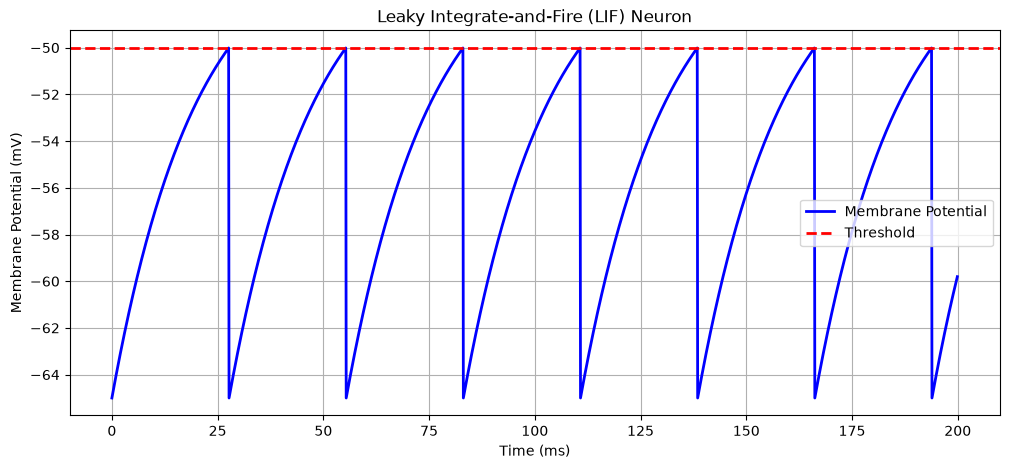

In [21]:
# ======================================
# Plot Membrane Potential
# ======================================

plt.figure(figsize=(12, 5))

plt.plot(time, V, color='blue', linewidth=2, label='Membrane Potential')

plt.axhline(
    y=V_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

plt.title("Leaky Integrate-and-Fire (LIF) Neuron")

plt.xlabel("Time (ms)")

plt.ylabel("Membrane Potential (mV)")

plt.legend()

plt.grid(True)

plt.show()

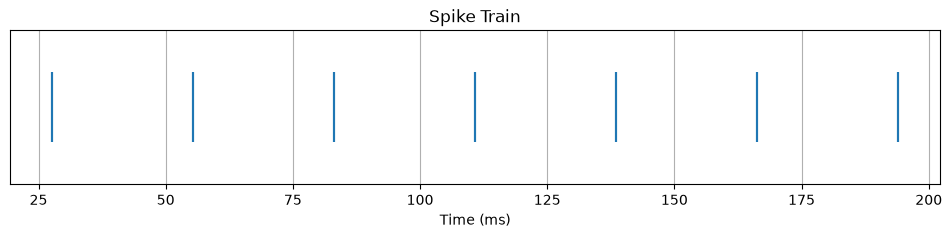

In [22]:
# ======================================
# Plot Spike Train
# ======================================

plt.figure(figsize=(12, 2))

plt.eventplot(spikes)

plt.title("Spike Train")

plt.xlabel("Time (ms)")

plt.yticks([])

plt.grid(True)

plt.show()

In [23]:
# ======================================
# Simulation Statistics
# ======================================

print("Simulation Time :", simulation_time, "ms")

print("Total Spikes :", len(spikes))

firing_rate = len(spikes) / (simulation_time / 1000)

print("Average Firing Rate :", round(firing_rate, 2), "Hz")

Simulation Time : 200 ms
Total Spikes : 14
Average Firing Rate : 70.0 Hz


In [24]:
# ======================================
# Save Figure
# ======================================

plt.figure(figsize=(12, 5))

plt.plot(time, V, color='blue', linewidth=2, label='Membrane Potential')

plt.axhline(
    y=V_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

plt.title("Leaky Integrate-and-Fire (LIF) Neuron")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")

plt.legend()
plt.grid(True)

plt.savefig(
    "../results/lif_membrane_potential.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figure saved successfully!")

Figure saved successfully!


# Effect of Input Current

The firing behaviour of a Leaky Integrate-and-Fire neuron depends strongly on the magnitude of the input current.

If the input current is too small, the membrane potential may never reach the firing threshold, and no spikes will be generated.

As the input current increases, the membrane potential rises more rapidly, causing the neuron to reach the threshold sooner and fire more frequently.

In this experiment, we simulate the neuron using different values of input current and observe how the firing rate changes.

In [27]:
I = 20

In [26]:
# ======================================
# Parameter Sweep: Input Current
# ======================================

input_currents = [5, 10, 15, 20, 25, 30, 35, 40]

firing_rates = []

for current in input_currents:

    # Initialize membrane potential
    V_temp = np.zeros(len(time))
    V_temp[0] = V_rest

    spike_count = 0

    # Simulate neuron
    for t in range(1, len(time)):

        dV = (-(V_temp[t-1] - V_rest) + R * current) * dt / tau

        V_temp[t] = V_temp[t-1] + dV

        if V_temp[t] >= V_threshold:

            spike_count += 1
            V_temp[t] = V_reset

    # Calculate firing rate
    firing_rate = spike_count / (simulation_time / 1000)

    firing_rates.append(firing_rate)

In [28]:
firing_rates

[0.0, 0.0, 0.0, 35.0, 50.0, 70.0, 85.0, 105.0]

In [29]:
print("Input Current (I)\tFiring Rate (Hz)")

for current, rate in zip(input_currents, firing_rates):
    print(f"{current}\t\t\t{rate:.2f}")

Input Current (I)	Firing Rate (Hz)
5			0.00
10			0.00
15			0.00
20			35.00
25			50.00
30			70.00
35			85.00
40			105.00


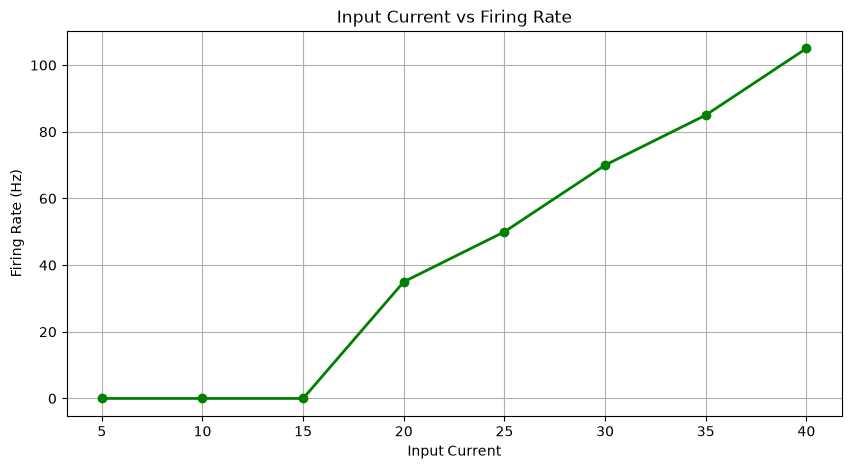

In [30]:
# ======================================
# Plot: Input Current vs Firing Rate
# ======================================

plt.figure(figsize=(10, 5))

plt.plot(
    input_currents,
    firing_rates,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Input Current vs Firing Rate")

plt.xlabel("Input Current")

plt.ylabel("Firing Rate (Hz)")

plt.grid(True)

plt.show()

In [31]:
# ======================================
# Save Analysis Figure
# ======================================

plt.figure(figsize=(10, 5))

plt.plot(
    input_currents,
    firing_rates,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Input Current vs Firing Rate")

plt.xlabel("Input Current")

plt.ylabel("Firing Rate (Hz)")

plt.grid(True)

plt.savefig(
    "../results/firing_rate_vs_current.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Analysis figure saved successfully!")

Analysis figure saved successfully!


# Discussion

The simulation demonstrates the behaviour of a Leaky Integrate-and-Fire (LIF) neuron under different levels of external input current.

## Observations

- For low input currents, the membrane potential rises slowly and may not reach the threshold, resulting in few or no spikes.
- Increasing the input current causes the membrane potential to rise more rapidly.
- As a result, the neuron reaches the threshold more frequently and generates spikes at a higher rate.
- The relationship between input current and firing rate is clearly visible in the analysis plot.

## Significance

The LIF neuron is one of the simplest computational neuron models and forms the basis of many Spiking Neural Networks (SNNs).

Its low computational complexity makes it suitable for FPGA, ASIC, and neuromorphic VLSI implementations where hardware efficiency is important.

# Conclusion

In this notebook, we implemented the Leaky Integrate-and-Fire (LIF) neuron model using Python.

The project demonstrated:

- Mathematical modelling of a biological neuron.
- Numerical simulation using the Forward Euler method.
- Spike generation based on a threshold mechanism.
- Visualization of membrane potential and spike trains.
- Analysis of the effect of input current on neuronal firing.

This notebook provides a simple but effective foundation for studying neuromorphic computing and can be extended to larger Spiking Neural Networks or hardware implementations.